In [4]:
import os
import torch
torch.manual_seed(12345)
import torch.nn.functional as F
from torch.nn import Linear
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import networkx as next

In [5]:
os.environ['Torch']=torch.__version__
print(torch.__version__)

2.6.0


In [6]:
from torch_geometric.data import Data
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

In [20]:
dataset=Planetoid(root='data/Planetoid',name='Cora',transform=NormalizeFeatures())

In [28]:
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Number of graphs: 1
Number of features: 1433
Number of classes: 7


In [41]:

# There is only one graph in the dataset, use it as new data object
data = dataset[0]
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Number of training nodes: {data.train_mask.sum()}')

Number of nodes: 2708
Number of edges: 10556
Number of training nodes: 140


In [33]:
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [36]:
data.train_mask.sum()

tensor(140)

In [40]:
data.train_mask

tensor([ True,  True,  True,  ..., False, False, False])

In [42]:
data.is_directed()

False

In [44]:
print(data.x.shape)

torch.Size([2708, 1433])


In [59]:
data.x[0][:200]

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.1111, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.1111, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [61]:
data.y.unique()

tensor([0, 1, 2, 3, 4, 5, 6])

In [63]:
data.edge_index.t()

tensor([[ 633,    0],
        [1862,    0],
        [2582,    0],
        ...,
        [ 598, 2707],
        [1473, 2707],
        [2706, 2707]])

In [66]:
data.is_undirected()

True

GNN network creation for node classification

In [91]:
from torch_geometric.nn import GCNConv

class GNN(torch.nn.Module):
    
    def __init__(self,hidden_dim):
        super(GNN,self).__init__()
        self.gcn1=GCNConv(dataset.num_features,hidden_dim)
        self.gcn2=GCNConv(hidden_dim,hidden_dim)
        self.out=torch.nn.Linear(hidden_dim,dataset.num_classes)

    def forward(self,x,edge_index):
        x=self.gcn1(x,edge_index)
        x=x.relu()
        x=F.dropout(x,p=0.5)
        # second message passing layer
        x = self.gcn2(x , edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.4)
        
        # Output layer 
        x = F.log_softmax(self.out(x), dim=1)
        return x

In [92]:
hidden_dim=16
model=GNN(hidden_dim)
model

GNN(
  (gcn1): GCNConv(1433, 16)
  (gcn2): GCNConv(16, 16)
  (out): Linear(in_features=16, out_features=7, bias=True)
)

In [93]:
device=torch.device('mps' if torch.mps.is_available else 'cpu')
model=model.to(device)
data=data.to(device)

In [94]:
device

device(type='mps')

In [95]:
lr=0.01
decay=5e-4
optimizer=torch.optim.Adam(model.parameters(),lr=lr,weight_decay=decay)

In [96]:
criterion=torch.nn.NLLLoss()
criterion

NLLLoss()

training and eval


In [224]:
def train(model,model_type):
    model.train()
    optimizer.zero_grad()
    if model_type=='GNN':
        out=model(data.x,data.edge_index)
    else:
        out=model(data.x)

    loss=criterion(out[data.train_mask],data.y[data.train_mask])            
    '''
    out[data.train_mask] this 
    data.train_mask = torch.tensor([True, False, True, False, True])
    out[data.train_mask]  
    # picks rows 0, 2, 4
    [[0.1, 0.7, 0.2],  # node 0
    [0.2, 0.2, 0.6],  # node 2
    [0.3, 0.4, 0.3]]  # node 4
    '''
    loss.backward()
    optimizer.step()
    return loss

def test(model,model_type):
    model.eval()
    if model_type=='GNN':
        out=model(data.x,data.edge_index)
    else:
        out=model(data.x)

    pred = out.argmax(dim=1)  
    # Check against ground-truth labels.
    test_correct = pred[data.test_mask] == data.y[data.test_mask]  
    # Derive ratio of correct predictions.
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  
    return test_acc




In [239]:
losses=[]
print('Graph Convolution Neural Network')
for epoch in range(0,3000):
    loss=train(model,'GNN')
    losses.append(loss.item())
    if epoch %300==0:
        print(f'Epoch: {epoch:02d},Loss:{loss:.4f}')

Graph Convolution Neural Network
Epoch: 00,Loss:0.1934
Epoch: 300,Loss:0.1394
Epoch: 600,Loss:0.2497
Epoch: 900,Loss:0.1693
Epoch: 1200,Loss:0.1402
Epoch: 1500,Loss:0.1585
Epoch: 1800,Loss:0.1213
Epoch: 2100,Loss:0.0846
Epoch: 2400,Loss:0.1402
Epoch: 2700,Loss:0.0735


In [226]:
out

tensor([[-6.3093e+00, -1.0447e+01, -7.5680e+00,  ..., -4.0220e+00,
         -6.4862e+00, -4.2546e+00],
        [-2.0555e+01, -8.7204e+00, -1.5284e+01,  ..., -1.6378e-04,
         -2.0888e+01, -1.5271e+01],
        [-1.1658e+01, -5.7552e+00, -5.7412e+00,  ..., -6.6225e-03,
         -9.4935e+00, -1.0025e+01],
        ...,
        [-1.2765e+00, -1.5594e+01, -1.3138e+01,  ..., -1.3424e+01,
         -1.7642e+01, -3.3463e-01],
        [-9.4738e+00, -1.2079e+01, -8.1735e+00,  ..., -2.2946e+00,
         -4.2904e+00, -7.8927e+00],
        [-5.0710e+00, -6.3490e+00, -2.5963e+00,  ..., -1.4893e+00,
         -3.4476e+00, -3.4880e+00]], device='mps:0',
       grad_fn=<LogSoftmaxBackward0>)

In [227]:
out[data.train_mask]

tensor([[-6.3093e+00, -1.0447e+01, -7.5680e+00, -3.6669e-02, -4.0220e+00,
         -6.4862e+00, -4.2546e+00],
        [-2.0555e+01, -8.7204e+00, -1.5284e+01, -1.9697e+01, -1.6378e-04,
         -2.0888e+01, -1.5271e+01],
        [-1.1658e+01, -5.7552e+00, -5.7412e+00, -9.2569e+00, -6.6225e-03,
         -9.4935e+00, -1.0025e+01],
        [-4.7124e-04, -8.1827e+00, -1.7299e+01, -1.3894e+01, -1.2991e+01,
         -8.6480e+00, -1.1254e+01],
        [-8.8909e+00, -1.0694e+01, -8.0694e+00, -1.3901e-01, -2.4207e+00,
         -3.2116e+00, -8.7876e+00],
        [-1.3923e+01, -3.9769e+00, -4.2335e-02, -1.3893e+01, -3.7887e+00,
         -1.5021e+01, -9.4311e+00],
        [-4.9321e-02, -3.5697e+00, -7.7631e+00, -5.9853e+00, -6.8373e+00,
         -4.3485e+00, -5.8027e+00],
        [-1.7655e+01, -2.4351e+01, -2.4792e+01, -2.0892e-03, -7.1291e+00,
         -6.6565e+00, -2.2421e+01],
        [-2.7424e+00, -5.8216e+00, -1.3141e+00, -6.8497e-01, -3.5861e+00,
         -3.7108e+00, -2.2291e+00],
        [-

In [228]:
data.y[data.train_mask]     #only those nodes values which are trained

tensor([3, 4, 4, 0, 3, 2, 0, 3, 3, 2, 0, 0, 4, 3, 3, 3, 2, 3, 1, 3, 5, 3, 4, 6,
        3, 3, 6, 3, 2, 4, 3, 6, 0, 4, 2, 0, 1, 5, 4, 4, 3, 6, 6, 4, 3, 3, 2, 5,
        3, 4, 5, 3, 0, 2, 1, 4, 6, 3, 2, 2, 0, 0, 0, 4, 2, 0, 4, 5, 2, 6, 5, 2,
        2, 2, 0, 4, 5, 6, 4, 0, 0, 0, 4, 2, 4, 1, 4, 6, 0, 4, 2, 4, 6, 6, 0, 0,
        6, 5, 0, 6, 0, 2, 1, 1, 1, 2, 6, 5, 6, 1, 2, 2, 1, 5, 5, 5, 6, 5, 6, 5,
        5, 1, 6, 6, 1, 5, 1, 6, 5, 5, 5, 1, 5, 1, 1, 1, 1, 1, 1, 1],
       device='mps:0')

In [229]:
data.y

tensor([3, 4, 4,  ..., 3, 3, 3], device='mps:0')

In [230]:
data

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])

In [231]:
pred=out.argmax(dim=1)

In [232]:
out.argmax(dim=0)

tensor([ 965,  589, 1739, 1701,   12,  739,  307], device='mps:0')

In [233]:
pred.shape

torch.Size([2708])

In [234]:
pred[data.test_mask].shape

torch.Size([1000])

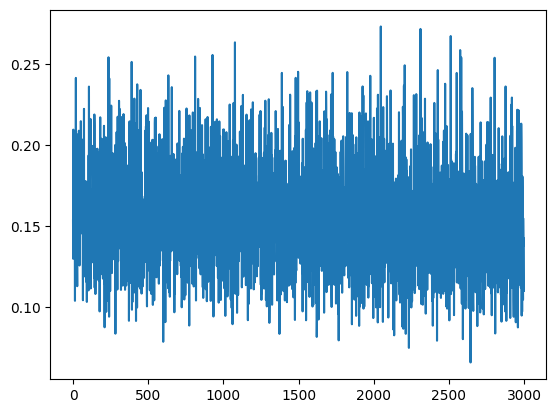

In [235]:
plt.plot(losses)

In [206]:

test_acc = test(model , 'GNN')
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.6210


In [221]:
class MLP(torch.nn.Module):
    def __init__(self,hidden_channel):
        super().__init__()

        self.lin1=Linear(dataset.num_features,hidden_channel)
        self.lin2=Linear(hidden_channel,dataset.num_classes)

    def forward(self,x):
        x=self.lin1(x)
        x=x.relu()
        x=F.dropout(x,p=0.5)
        x=F.log_softmax(self.lin2(x))
        return x
    
model_mlp=MLP(hidden_channel=16).to(device)


In [222]:
model_mlp

MLP(
  (lin1): Linear(in_features=1433, out_features=16, bias=True)
  (lin2): Linear(in_features=16, out_features=7, bias=True)
)

In [240]:
losses=[]
print('MLP')
for epoch in range(0,3000):
    loss=train(model_mlp,'MLP')
    losses.append(loss.item())
    if epoch%300==0:
        print(f'Epochs :{epoch:03d},Loss: {loss:.4f}')

MLP
Epochs :000,Loss: 1.9607
Epochs :300,Loss: 1.9603
Epochs :600,Loss: 1.9611
Epochs :900,Loss: 1.9604
Epochs :1200,Loss: 1.9607
Epochs :1500,Loss: 1.9602
Epochs :1800,Loss: 1.9607
Epochs :2100,Loss: 1.9600
Epochs :2400,Loss: 1.9602
Epochs :2700,Loss: 1.9596
